### Análise de Dados de Clientes de um Shopping Center ###

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [6]:
FILE = '/content/Mall_Customers.csv'
df = pd.read_csv(FILE)

- Exploração dos dados

In [7]:
display(df.head())
display(df.dtypes)
display(df.isnull().sum())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


,0
CustomerID,int64
Gender,object
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


- Removendo a coluna ID

- Renomeando colunas

In [9]:
df.drop('CustomerID', axis=1, inplace=True)

In [10]:


colunas = {
    'Gender': 'Gênero',
    'Age': 'Idade',
    'Annual Income (k$)': 'Renda Anual',
    'Spending Score (1-100)': 'Pontuação de Gastos'
}

df.rename(columns=colunas, inplace=True)



- Renda anual por genero

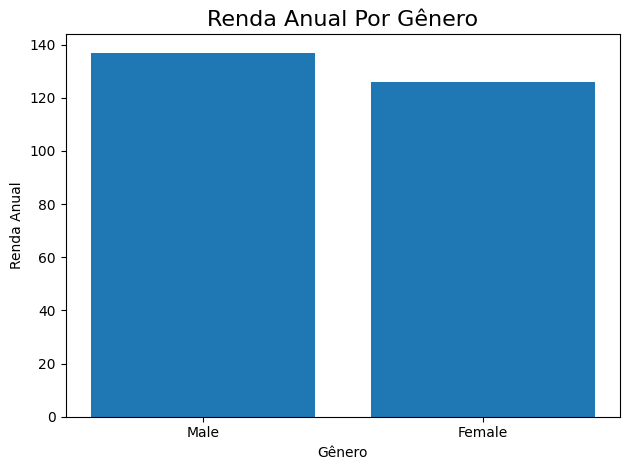

In [32]:
plt.bar(df['Gênero'], df['Renda Anual'])
plt.title('Renda Anual Por Gênero', fontsize=16)
plt.xlabel('Gênero')
plt.ylabel('Renda Anual')
plt.tight_layout()
plt.show()

In [30]:
renda_masculina = df[df['Gênero'] == 'Male']['Renda Anual']
renda_feminina = df[df['Gênero'] == 'Female']['Renda Anual']
estat_t,p_valor = stats.ttest_ind(renda_masculina, renda_feminina)

print(f'Estatística T: {estat_t:.4f}')
print(f'P valor: {p_valor:.4f}')

Estatística T: 0.7950
P valor: 0.4276


### Conclusão ###
> A diferença na renda média entre os grupos feminino e masculino não é estatisticamente significativa. Por isso, não há evidências para rejeitar a hipótese nula de que as médias são iguais.



- Pontuação de gasto por genero

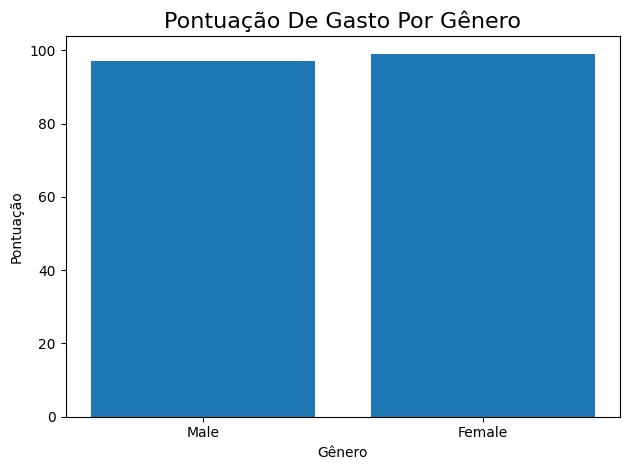

In [35]:
plt.bar(df['Gênero'], df['Pontuação de Gastos'])
plt.title('Pontuação De Gasto Por Gênero', fontsize=16)
plt.xlabel('Gênero')
plt.ylabel('Pontuação')
plt.tight_layout()
plt.show()


In [36]:
score_masculino = df[df['Gênero'] == 'Male']['Pontuação de Gastos']
score_feminino = df[df['Gênero'] == 'Female']['Pontuação de Gastos']
estat_t,p_valor = stats.ttest_ind(score_masculino, score_feminino)

print(f'Estatística T: {estat_t:.4f}')
print(f'P valor: {p_valor:.4f}')

Estatística T: -0.8190
P valor: 0.4137


### Conclusão ###
> Não há evidências para afirmar que a pontuação de gastos por gênero é significativa; a hipótese nula não pode ser rejeitada.



- Correlação entre idade e pontuação de gastos

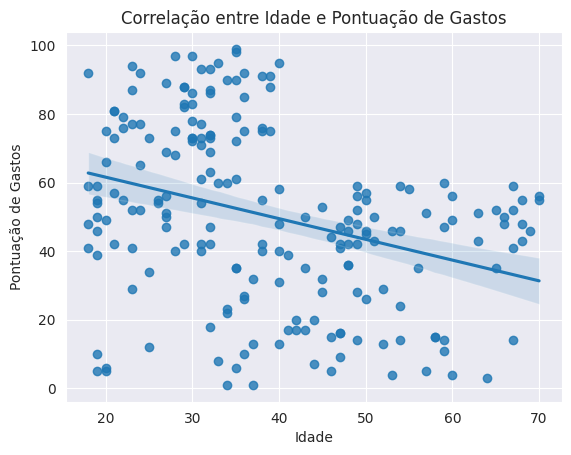

In [42]:
sns.set_style('darkgrid')
sns.regplot(data=df, x='Idade', y='Pontuação de Gastos')
plt.title('Correlação entre Idade e Pontuação de Gastos')
plt.xlabel('Idade')
plt.ylabel('Pontuação de Gastos')
plt.show()

- Correlação entre idade e renda

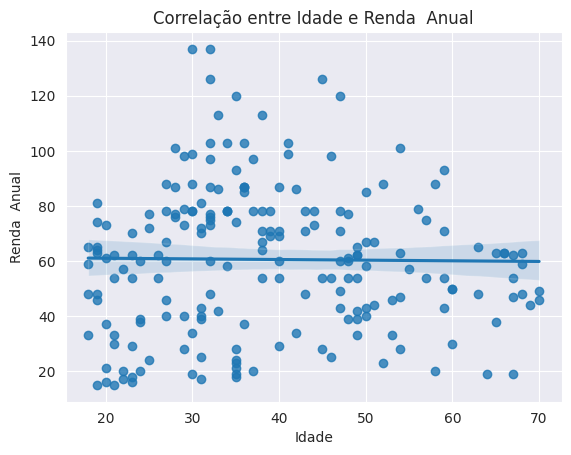

In [43]:
sns.set_style('darkgrid')
sns.regplot(data=df, x='Idade', y='Renda Anual')
plt.title('Correlação entre Idade e Renda  Anual')
plt.xlabel('Idade')
plt.ylabel('Renda  Anual')
plt.show()

In [46]:
corr = df[['Idade', 'Renda Anual', 'Pontuação de Gastos']].corr()
display(corr)

,Idade,Renda Anual,Pontuação de Gastos
Idade,1.000000,-0.012398,-0.327227
Renda Anual,-0.012398,1.000000,0.009903
Pontuação de Gastos,-0.327227,0.009903,1.000000


# Conclusões do Projeto

## Análise de Significância Estatística
* **Renda Média vs Gênero:** Não há evidências estatísticas de diferença significativa.
* **Pontuação de Gastos vs Gênero:** Não há evidências estatísticas de diferença significativa.

## Análise de Correlação
* **Idade vs Pontuação de Gastos:** Correlação fraca e negativa.
* **Idade vs Renda Anual:** Correlação nula (inexistente).